**Overview**  
This notebook describes following stages:
1. Creating functions to:
    - perform search for optimal algorithm parameters;
    - train model;
    - evaluate trained model on the test set;
    - plot ROC-AUC curve
2. Evaluate following algorithms for the classification task using random splitting strategy:
    - Logistic regression;
    - Random Forest;
    - Gradient Boosting as implemented in XGBoost;
    - Support Vector Machines;
    - K-Nearest Neighborrs
3. Creare dataframe with evaluation results


In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score, precision_score, roc_curve, recall_score
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from hyperopt import tpe, Trials, hp, fmin, STATUS_OK
from functools import partial
from sklearn.neighbors import KNeighborsClassifier

from sklearn.linear_model import Lasso
from sklearn.feature_selection import SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold

First, let's import datasets and y-target, created earlier:

In [2]:
with open('X_padel.pickle', 'rb') as input:
    X_padel = pickle.load(input)

In [3]:
with open('X_standard.pickle', 'rb') as input:
    X_standard = pickle.load(input)

In [4]:
with open('y.pickle', 'rb') as input:
    target = pickle.load(input)


To facilitate automatic calculation of metrics and asiggning labels, we will create dictionaries with imported descriptor datasets - PaDEL and RDKit (Standard)

In [5]:
descriptors_dict = {'Standard':X_standard, 'Padel':X_padel}

Here we instantiate scores dictionary that will contain performance metrics 

In [6]:
scores = {'Descriptors':[], 'Full or PCA':[], 'Presicion_CV':[], 'Stddev_CV':[], 'Accuracy':[], 'F1 - score':[], 'ROC-AUC Score':[], 'Estimator':[], 'Recall score':[], 'Precision score':[]}

The function below performs several tasks:
1. First, it create matplotlib figure object and axes with two fields,
2. Then for each of two datasets in descriptors dictionary (RDKit and PaDEL), we:
    - Split dataset into training and testing subsets in a random manner;
    - Instantiate a pipeline with parameters provided by HyperOpt;
    - Search for optimal parameters that yield minimum negatvie mean CV precision using [hyperopt package](http://hyperopt.github.io/hyperopt/). Search is made over 50 iterations;
    - Extract the best hyperparameters and train model on X_train and y_train;
    - Calculate different metrics (Precision, Accuracy, F1-Score, ROC_AUC score) on the test set and append them to the "Scores" dictionary, as well the type of descriptor sets and name of the algorithm
    - Finally, we plot ROC-AUC curves and save them to folder

In [8]:
def calculate_to_score(pipe, estimator_name, param_grid, descriptors_dict = descriptors_dict, target=target, type = 'Full'):
    fig, axes = plt.subplots(1, 2, figsize = (16,8))
    i = 0
    for key, value in descriptors_dict.items():
        X_train, X_test, y_train, y_test = train_test_split(value, target, random_state = 0)
        def objective(params, X, target):
            #pipe = make_pipeline(MinMaxScaler(), estimator)
            pipe.set_params(**params)
            score = cross_val_score(pipe, X, target, cv = 10, scoring = 'precision')
            return {'loss':-score.mean(), 'stddev':score.std(),  'status':STATUS_OK, 'Trained_model':pipe}
        trials = Trials()
        best = fmin(partial(objective, X = X_train, target = y_train), space = param_grid, trials = trials, algo = tpe.suggest, max_evals=  50)
        print(best)
        best_model_and_properties = get_best_model_from_trials(trials)

        
        print('Loss is {}'.format(best_model_and_properties[2]))
        print('Standard deviation is {}'.format(best_model_and_properties[1]))
        best_estimator  = best_model_and_properties[0]
        scores['Presicion_CV'].append(best_model_and_properties[2])
        scores['Stddev_CV'].append(best_model_and_properties[1])


        
        best_estimator.fit(X_train, y_train)
        predictions = best_estimator.predict(X_test)
        probs = best_estimator.predict_proba(X_test)[:,1]
        scores['Descriptors'].append(key)
        scores['Accuracy'].append(accuracy_score(y_test, predictions))
        scores['F1 - score'].append(f1_score(y_test, predictions))
        scores['ROC-AUC Score'].append(roc_auc_score(y_test, probs))
        scores['Recall score'].append(recall_score(y_test, predictions))
        scores['Precision score'].append(precision_score(y_test, predictions))
        scores['Full or PCA'].append(type)
        scores['Estimator'].append(estimator_name)
        fpr, tpr, _ = roc_curve(y_test, probs)
        axes[i].plot(fpr, tpr)
        axes[i].plot([0,1],[0,1], 'k--')
        axes[i].set_xlim(0,1)
        axes[i].set_ylim(0,1)
        axes[i].set_title('ROC-AUC Curve for {} descriptors'.format(key))
        axes[i].set_xlabel('False positive rate')
        axes[i].set_ylabel('True positive rate')
        i += 1
    plt.tight_layout()
    plt.savefig('ROC_AUC_all_temps_random/'+estimator_name+'_'+type+'.png')

Subfunction below is made to retrieve the best model from Trials object ans is used in main function

In [9]:
def get_best_model_from_trials(trials):
    valid_trial_list = [trial for trial in trials if trial['result']['status'] == STATUS_OK]
    losses = [ float(trial['result']['loss']) for trial in valid_trial_list]
    index_having_minumum_loss = np.argmin(losses)
    best_trial_obj = valid_trial_list[index_having_minumum_loss]
    return best_trial_obj['result']['Trained_model'], best_trial_obj['result']['stddev'], -best_trial_obj['result']['loss']

We start with **logistic regression**

In [31]:
pipe = Pipeline([('var_sel', VarianceThreshold(threshold=0.1)), ('scaler', StandardScaler()), 
                 ('logisticregression',LogisticRegression(max_iter=10000))])

Parameters grid defines the range of hyperparameters, which is used for search during optimization

In [33]:
param_grid = {'var_sel__threshold':hp.uniform(label = 'threshold', low = 0, high  = 0.4), 
             'logisticregression__C':hp.loguniform(label = 'C', low = -4*np.log(10), high  = 2*np.log(10))}

100%|███████████████████████████████████████████████| 50/50 [01:04<00:00,  1.29s/trial, best loss: -0.7406042451912016]
{'C': 0.002176585943494618, 'threshold': 0.01417908386157687}
Loss is 0.7406042451912016
Standard deviation is 0.06108763966510448
100%|███████████████████████████████████████████████| 50/50 [01:15<00:00,  1.51s/trial, best loss: -0.7547793880837359]
{'C': 0.013075364913189612, 'threshold': 0.02848789538868185}
Loss is 0.7547793880837359
Standard deviation is 0.049965410825479326


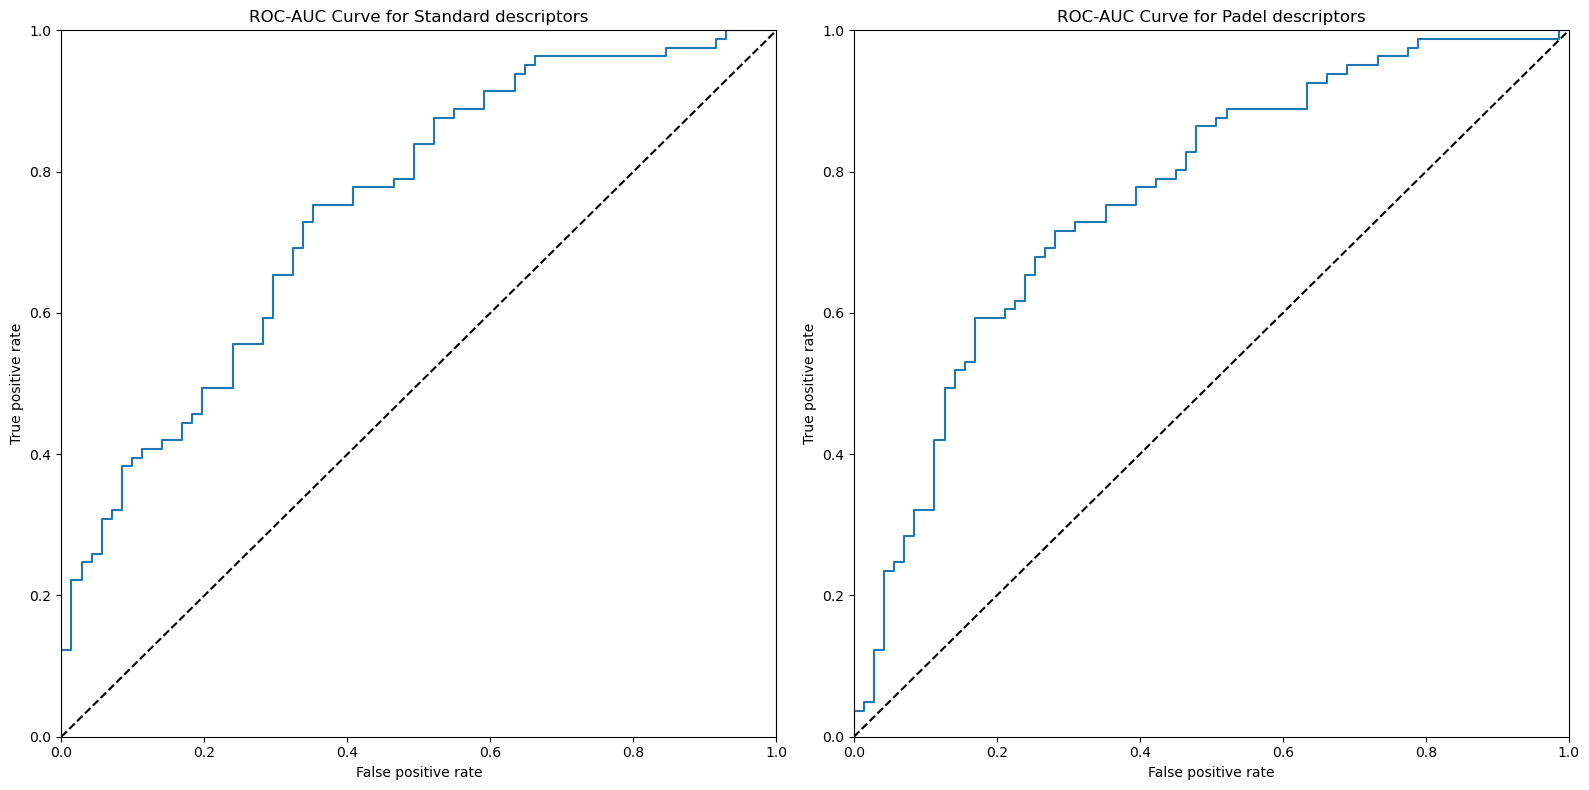

In [35]:
calculate_to_score(pipe, estimator_name='Logistic Regression', 
                   param_grid = param_grid)

At this stage, we insert PCA into a pipeline to check if the dimensionality reduction can improve predictive performance

100%|███████████████████████████████████████████████| 50/50 [01:04<00:00,  1.28s/trial, best loss: -0.7288759945424113]
{'C': 0.027668633106095478, 'threshold': 0.014564354975596628}
Loss is 0.7288759945424113
Standard deviation is 0.057918752844203586
100%|███████████████████████████████████████████████| 50/50 [01:11<00:00,  1.43s/trial, best loss: -0.7473373237068889]
{'C': 0.2826520204476484, 'threshold': 0.01994989897059006}
Loss is 0.7473373237068889
Standard deviation is 0.04128468157722604


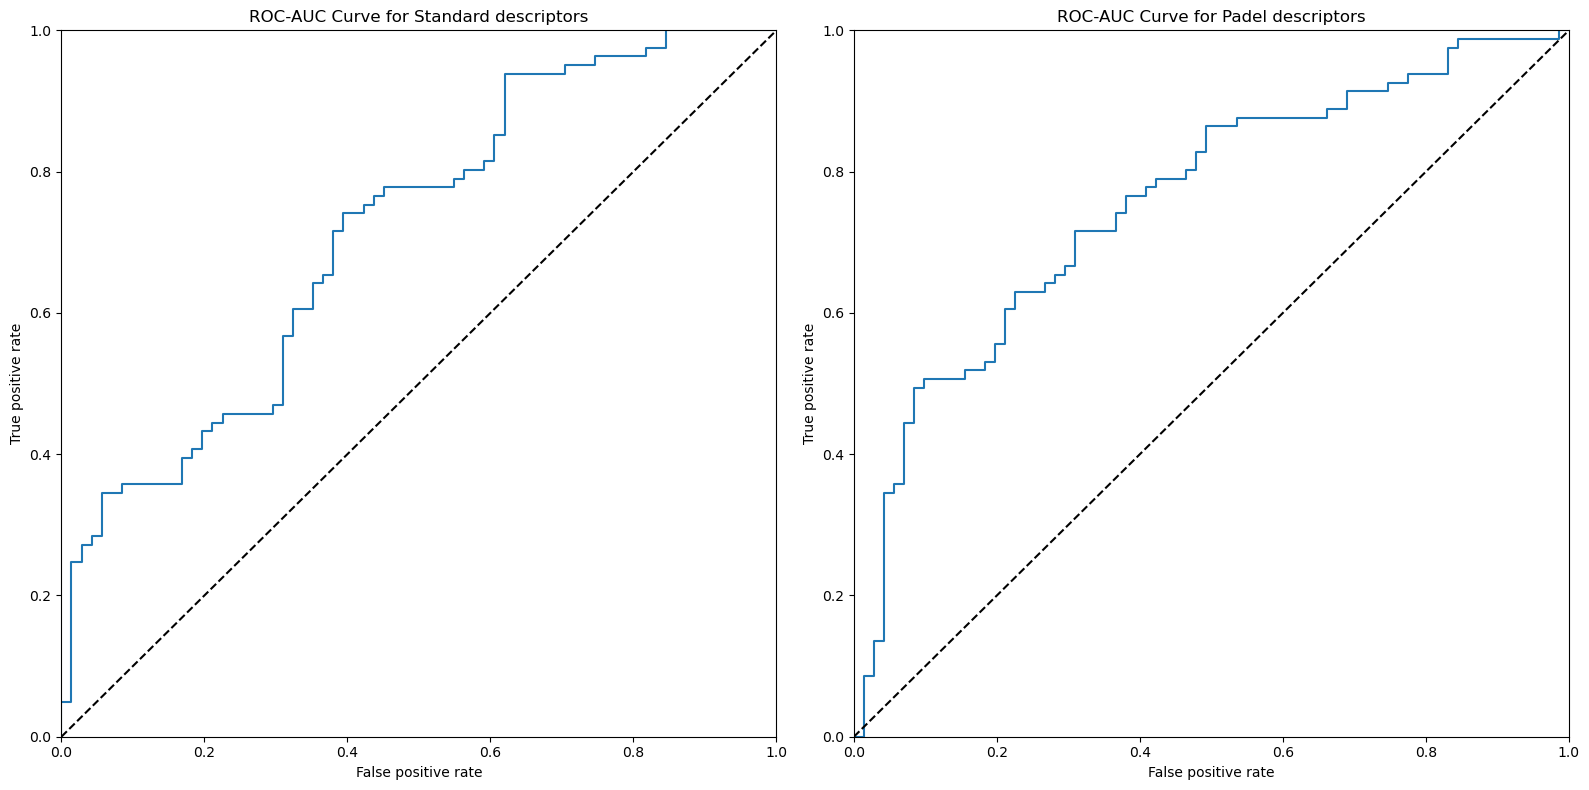

In [36]:
pipe = Pipeline([('var_sel', VarianceThreshold(threshold=0.1)), ('scaler', StandardScaler()), ('PCA', PCA(n_components = 50)), 
                 ('logisticregression',LogisticRegression(max_iter=10000))])

calculate_to_score(pipe, estimator_name='Logistic Regression', 
                   param_grid = param_grid, type = 'PCA')

Let's proceed with other algorithms. The first one will be
**Random Forest Classification**

In [37]:
pipe = Pipeline([('varsel', VarianceThreshold()),('randomforest', RandomForestClassifier(n_jobs = -1))])

In [38]:
space={'varsel__threshold':hp.uniform(label = 'threshold', low = 0, high  = 0.4),
    'randomforest__max_depth':hp.randint('max_depth',1,50),  'randomforest__max_features':hp.choice('max_features', [None, 'sqrt', 'log2']),
       'randomforest__min_samples_split':hp.randint('min_samples_split', 2, 8),
       'randomforest__min_samples_leaf': hp.randint('min_samples_leaf', 1, 10),
      'randomforest__n_estimators':hp.randint('n_estimators',50, 500),
      'randomforest__criterion': hp.choice('criterion', ["gini", "entropy", "log_loss"])}

100%|███████████████████████████████████████████████| 50/50 [16:48<00:00, 20.18s/trial, best loss: -0.8107687352627384]
{'criterion': 2, 'max_depth': 20, 'max_features': 0, 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 183, 'threshold': 0.2639597634291317}
Loss is 0.8107687352627384
Standard deviation is 0.061826980509851276
100%|███████████████████████████████████████████████| 50/50 [31:14<00:00, 37.49s/trial, best loss: -0.8231315665011317]
{'criterion': 2, 'max_depth': 19, 'max_features': 0, 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 169, 'threshold': 0.0021334637482740837}
Loss is 0.8231315665011317
Standard deviation is 0.045948940270794845


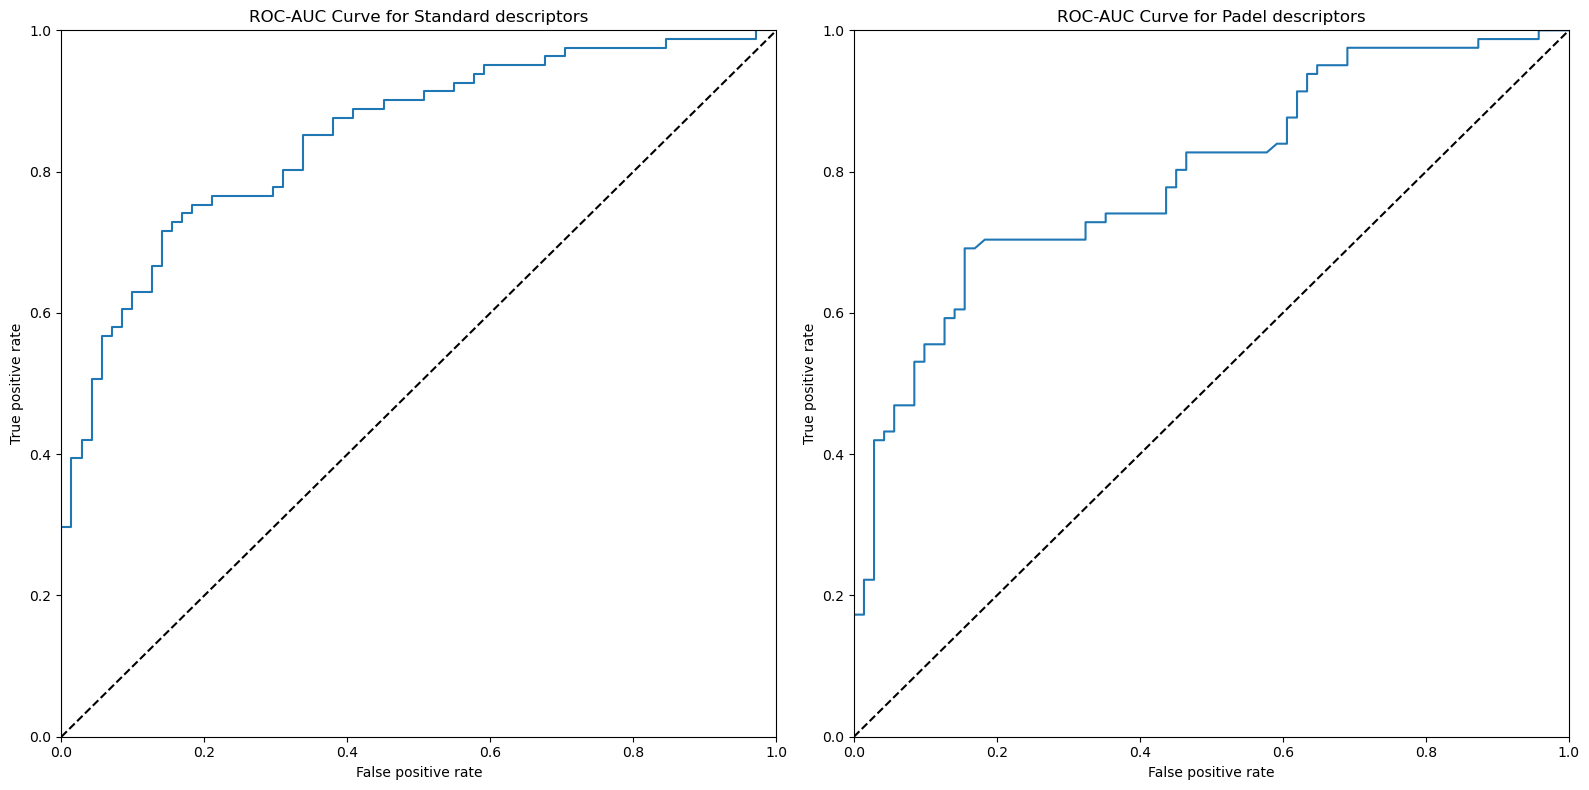

In [39]:
calculate_to_score(pipe, estimator_name = 'Random Forest', param_grid =  space,
                   descriptors_dict=descriptors_dict,
                   target=target,type = 'Full')
               

In [40]:
pipe = Pipeline([('varsel', VarianceThreshold()), ('scaler', StandardScaler()), ('PCA', PCA(n_components = 50)),('randomforest', RandomForestClassifier(n_jobs = -1))])

100%|███████████████████████████████████████████████| 50/50 [21:00<00:00, 25.20s/trial, best loss: -0.8105630373846265]
{'criterion': 1, 'max_depth': 40, 'max_features': 0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 348, 'threshold': 0.3060571205222056}
Loss is 0.8105630373846265
Standard deviation is 0.04820177361097252
100%|████████████████████████████████████████████████| 50/50 [35:03<00:00, 42.07s/trial, best loss: -0.819531317313926]
{'criterion': 2, 'max_depth': 38, 'max_features': 0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 126, 'threshold': 0.043252451285163224}
Loss is 0.819531317313926
Standard deviation is 0.04144376205792323


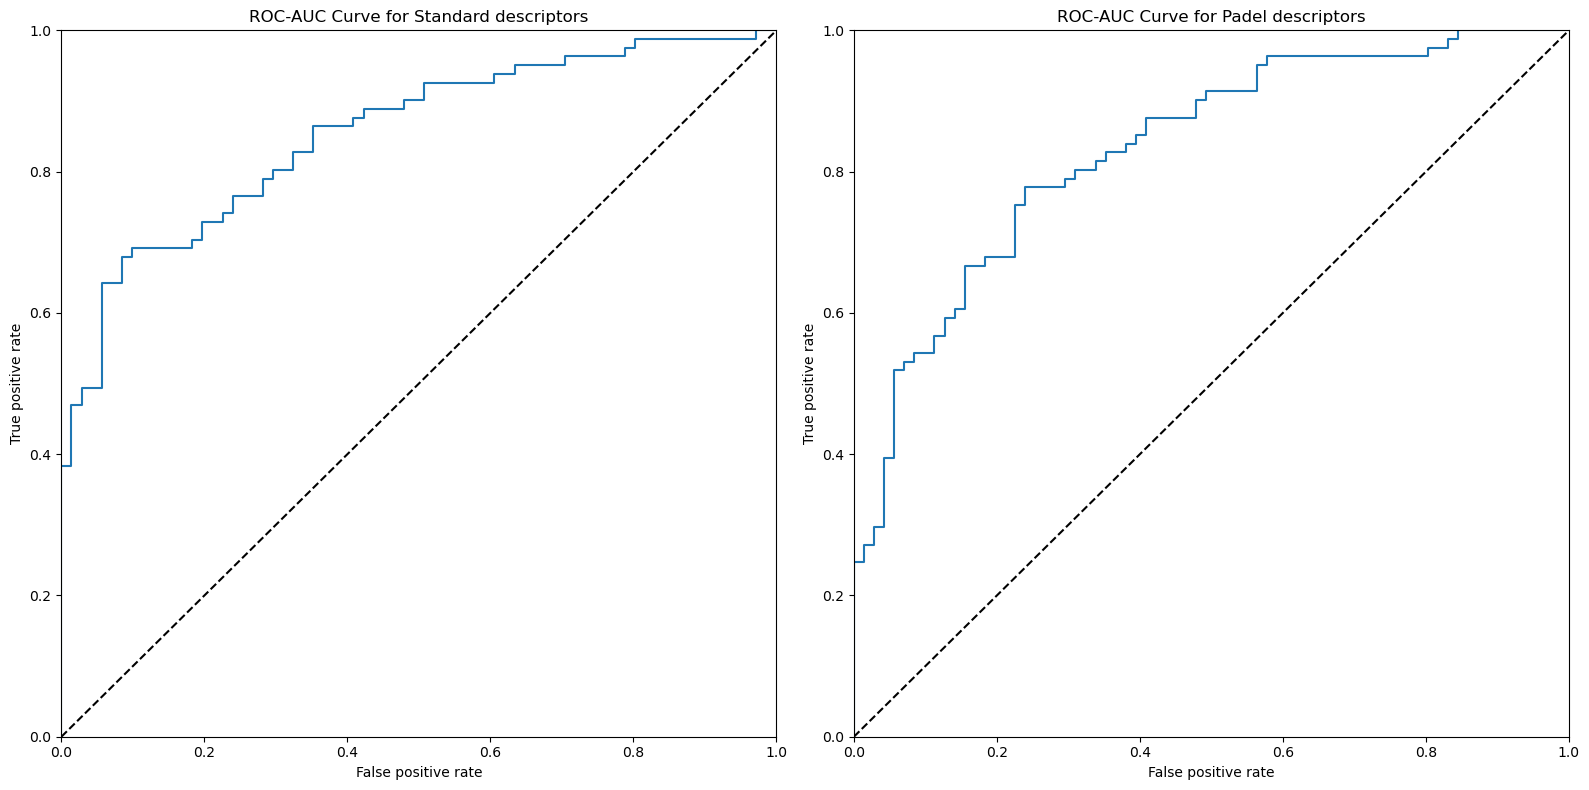

In [41]:
pipe = Pipeline([('varsel', VarianceThreshold()),('randomforest', RandomForestClassifier(n_jobs = -1))])

calculate_to_score(pipe, estimator_name = 'Random Forest', param_grid =  space,
                   target=target,                   type = 'PCA')


**XGBoost**

In [42]:
pipe = Pipeline([('varsel', VarianceThreshold()),('xgbclassifier', XGBClassifier(n_jobs = -1))])

In [43]:
space = {'varsel__threshold':hp.uniform(label = 'threshold', low = 0, high  = 0.4),
        'xgbclassifier__n_estimators':hp.randint('n_estimators', 1, 30),
         'xgbclassifier__learning_rate': hp.loguniform('learning_rate', low = -4*np.log(10), high  = 2*np.log(10)),
         'xgbclassifier__reg_alpha':hp.loguniform(label = 'reg_alpha', low = -4*np.log(10), high  = 2*np.log(10)),
         'xgbclassifier__max_depth':hp.randint('max_depth', 1, 100)}

 18%|████████▋                                       | 9/50 [00:54<04:51,  7.11s/trial, best loss: -0.8145223938702199]

C:\Users\T.Unusov\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



 22%|██████████▎                                    | 11/50 [01:02<03:35,  5.52s/trial, best loss: -0.8145223938702199]

C:\Users\T.Unusov\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



 24%|███████████▎                                   | 12/50 [01:06<03:06,  4.91s/trial, best loss: -0.8145223938702199]

...

 80%|█████████████████████████████████████▌         | 40/50 [04:15<01:25,  8.52s/trial, best loss: -0.8465610476480041]

C:\Users\T.Unusov\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))

C:\Users\T.Unusov\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



 86%|████████████████████████████████████████▍      | 43/50 [04:23<00:33,  4.74s/trial, best loss: -0.8465610476480041]

C:\Users\T.Unusov\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



100%|███████████████████████████████████████████████| 50/50 [05:12<00:00,  6.25s/trial, best loss: -0.8465610476480041]
{'learning_rate': 0.2603968926876514, 'max_depth': 56, 'n_estimators': 29, 'reg_alpha': 0.24159151829622807, 'threshold': 0.08401596672808008}
Loss is 0.8465610476480041
Standard deviation is 0.054515784882212134


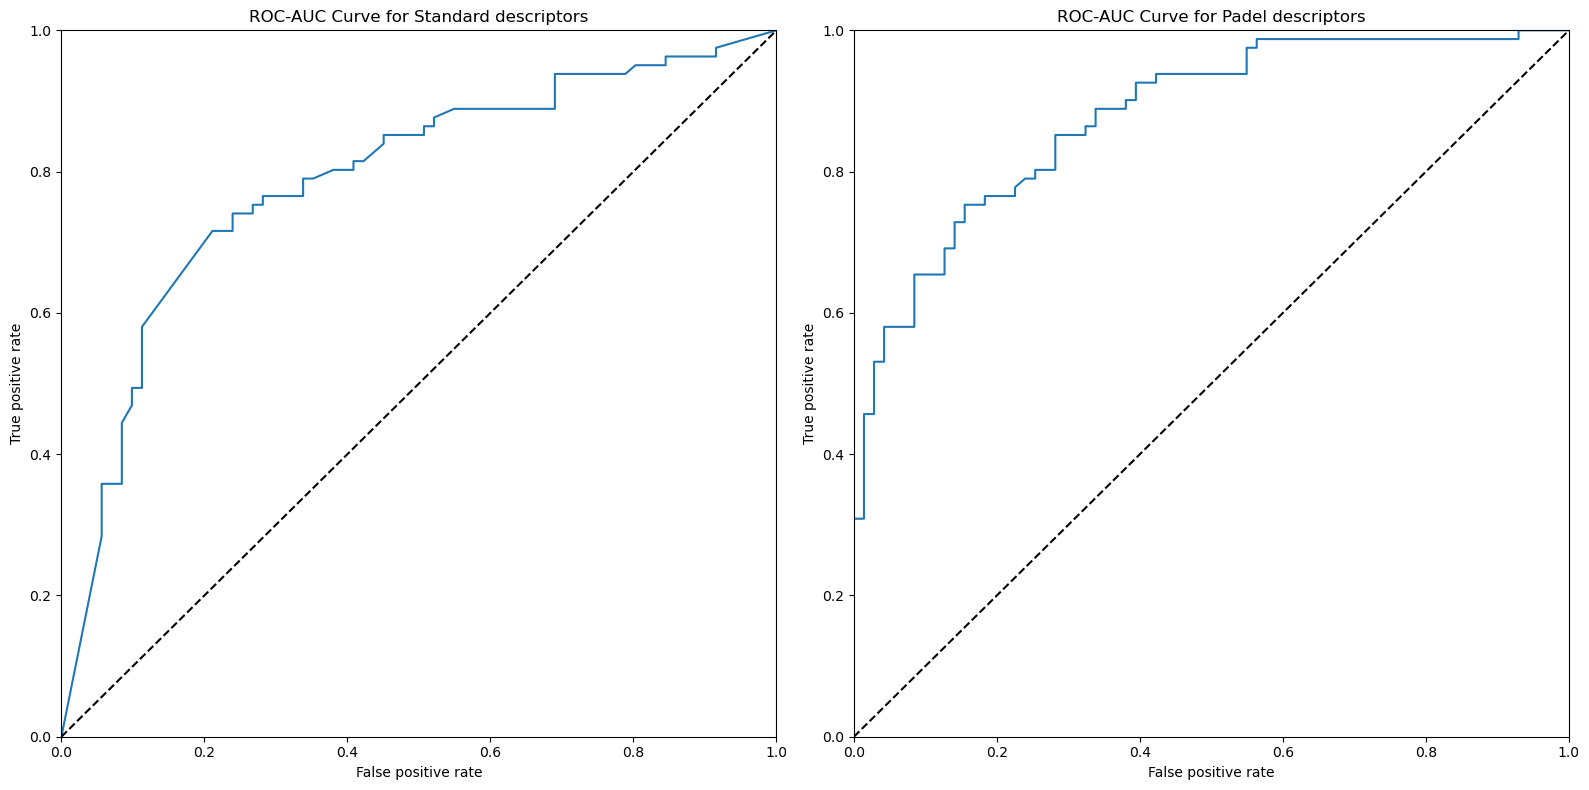

In [44]:
calculate_to_score(pipe, estimator_name='Gradient boosting', param_grid = space,
                   descriptors_dict=descriptors_dict,
                   target=target,
                   type = 'Full')

 56%|██████████████████████████▎                    | 28/50 [01:14<00:59,  2.69s/trial, best loss: -0.7365881015120146]

C:\Users\T.Unusov\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



 60%|████████████████████████████▏                  | 30/50 [01:20<00:56,  2.80s/trial, best loss: -0.7365881015120146]

C:\Users\T.Unusov\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



 92%|███████████████████████████████████████████▏   | 46/50 [02:05<00:12,  3.05s/trial, best loss: -0.7505080716385064]

...

 90%|██████████████████████████████████████████▎    | 45/50 [01:55<00:11,  2.38s/trial, best loss: -0.7707518105239003]

C:\Users\T.Unusov\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



 92%|███████████████████████████████████████████▏   | 46/50 [01:57<00:09,  2.28s/trial, best loss: -0.7707518105239003]

C:\Users\T.Unusov\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



100%|███████████████████████████████████████████████| 50/50 [02:06<00:00,  2.54s/trial, best loss: -0.7716379308966966]
{'learning_rate': 0.33079439160343904, 'max_depth': 29, 'n_estimators': 26, 'reg_alpha': 0.4022894278156661, 'threshold': 0.07570592165194046}
Loss is 0.7716379308966966
Standard deviation is 0.05692269415206558


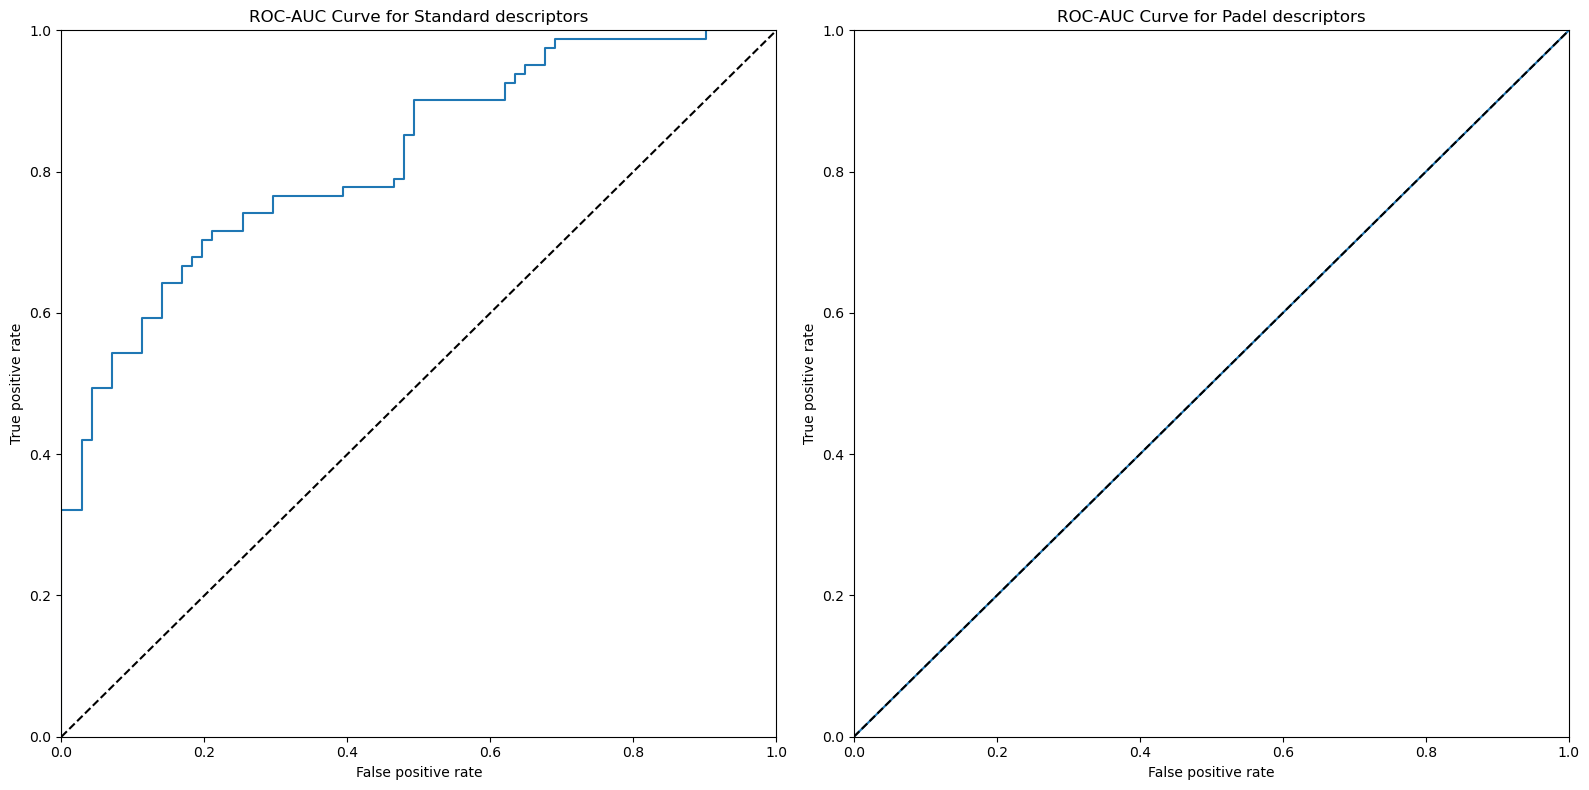

In [45]:
pipe = Pipeline([('varsel', VarianceThreshold()),('scaler', StandardScaler()), ('PCA', PCA(n_components = 50)),('xgbclassifier', XGBClassifier(n_jobs = -1))])

calculate_to_score(pipe, estimator_name='Gradient boosting', param_grid = space,
                   target=target,
                   type = 'PCA')

**SVM**

In [21]:
pipe = Pipeline([('varsel',VarianceThreshold()),
                 ('scaler',StandardScaler()),
                 ('model_sel',SelectFromModel(LogisticRegression(max_iter=10000))),
                 ('svc', SVC(probability=True))])

In [23]:
space = {'varsel__threshold':hp.uniform(label = 'threshold', low = 0, high  = 0.4),
         'model_sel__estimator__C':hp.loguniform(label = 'alpha', low = -1, high =2),
    'svc__C':hp.loguniform('C', -3*np.log(10), 1*np.log(10)),
         'svc__kernel':hp.choice('kernel', ['rbf','poly','linear', 'sigmoid']),
         'svc__degree':hp.choice('degree', [2,3]),
         'svc__gamma':hp.choice('gamma', ['scale', 'auto']),
         'svc__coef0':hp.loguniform('coef0', -3*np.log(10), 0*np.log(10))}

100%|███████████████████████████████████████████████| 50/50 [02:07<00:00,  2.54s/trial, best loss: -0.7763506101741396]
{'C': 0.1576354953236145, 'alpha': 0.5980028195628542, 'coef0': 0.01978126170339192, 'degree': 1, 'gamma': 1, 'kernel': 1, 'threshold': 0.2469021965395567}
Loss is 0.7763506101741396
Standard deviation is 0.12459547424318855
100%|███████████████████████████████████████████████| 50/50 [02:36<00:00,  3.13s/trial, best loss: -0.7593409888334846]
{'C': 0.3790512339428112, 'alpha': 7.141115503339832, 'coef0': 0.012991002628568057, 'degree': 1, 'gamma': 1, 'kernel': 1, 'threshold': 0.3596378492477796}
Loss is 0.7593409888334846
Standard deviation is 0.06693916302500416


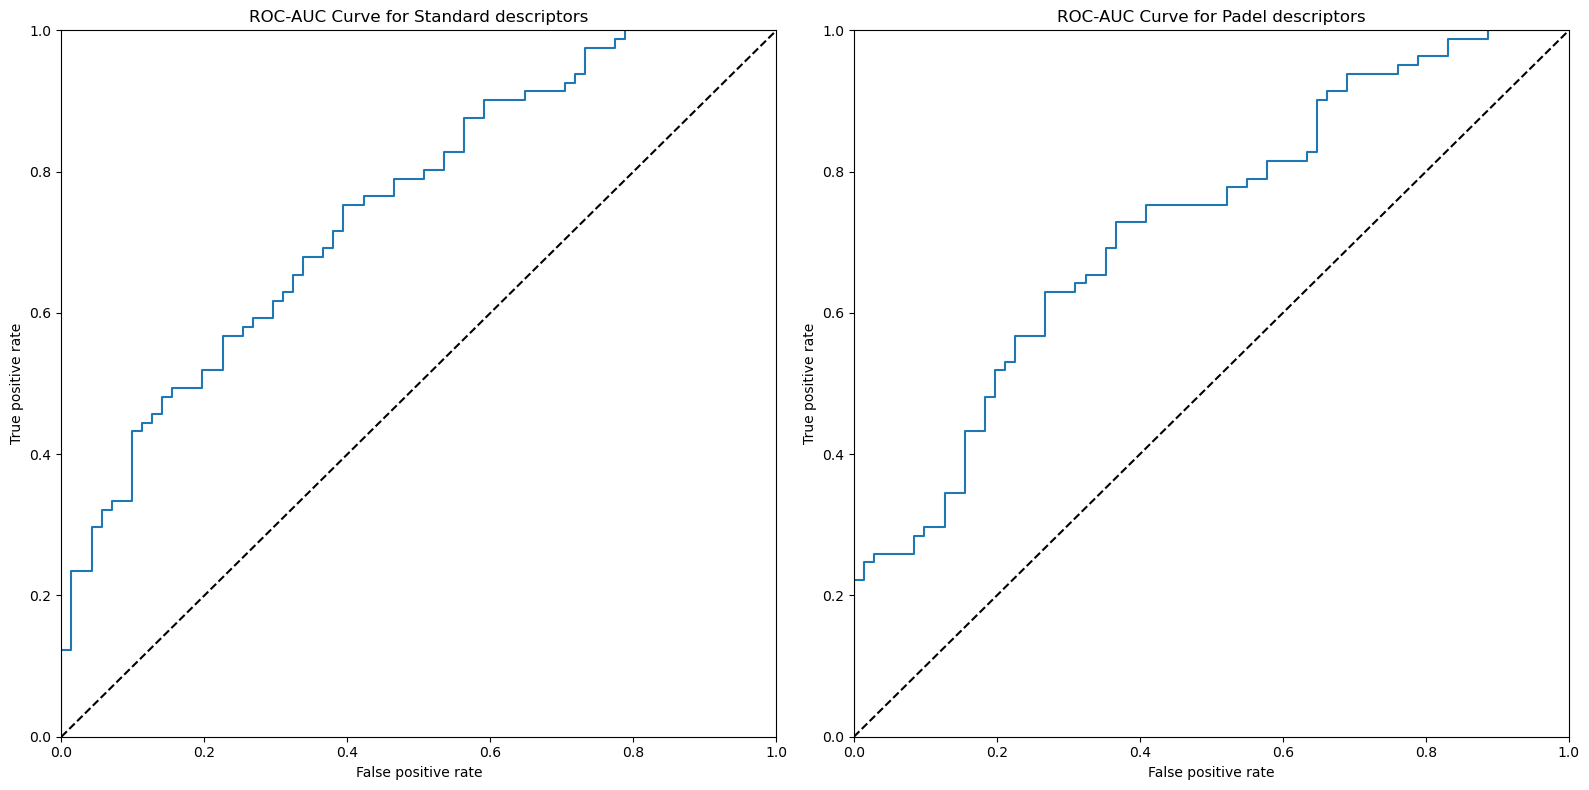

In [25]:


calculate_to_score(pipe, estimator_name = 'SVC', param_grid = space, descriptors_dict=descriptors_dict, target = target, type = 'Full')
                                                                


100%|███████████████████████████████████████████████| 50/50 [01:50<00:00,  2.21s/trial, best loss: -0.7037661227661227]
{'C': 2.0443736702536177, 'alpha': 2.0672526695573703, 'coef0': 0.043496727752688626, 'degree': 0, 'gamma': 1, 'kernel': 0, 'threshold': 0.07692317115597895}
Loss is 0.7037661227661227
Standard deviation is 0.06305761396151008
100%|███████████████████████████████████████████████| 50/50 [02:03<00:00,  2.47s/trial, best loss: -0.7714925656829704]
{'C': 5.132488781499649, 'alpha': 0.7253427113223803, 'coef0': 0.3478904351654673, 'degree': 1, 'gamma': 1, 'kernel': 1, 'threshold': 0.2924951587828218}
Loss is 0.7714925656829704
Standard deviation is 0.04909803748422503


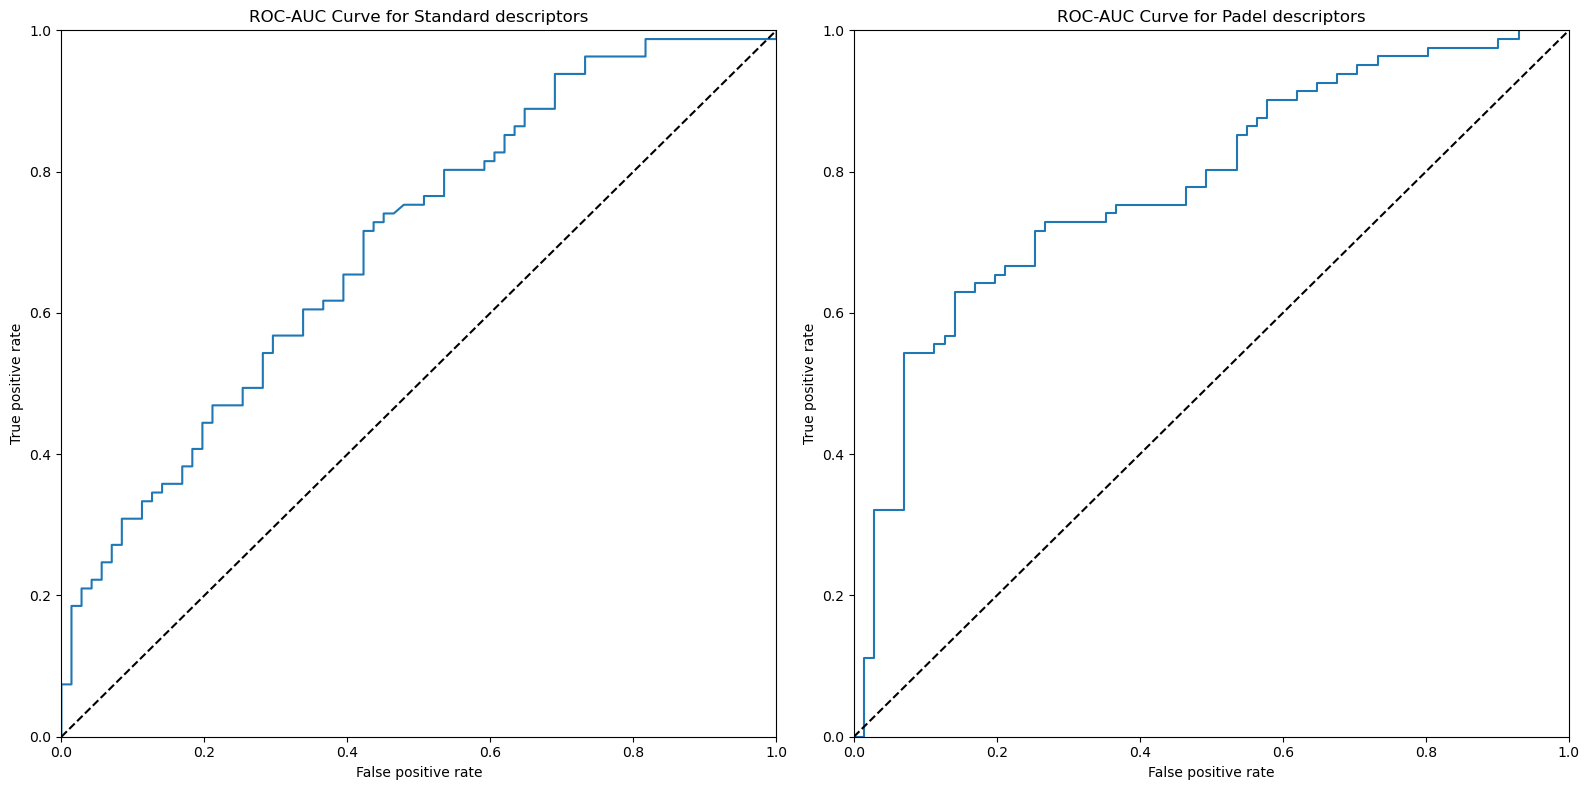

In [26]:
pipe = Pipeline([('varsel',VarianceThreshold()),
                 ('scaler',StandardScaler()),
                 ('PCA', PCA(n_components = 50)),
                 ('model_sel',SelectFromModel(LogisticRegression(max_iter=10000))),
                 ('svc', SVC(probability=True))])

calculate_to_score(pipe, estimator_name = 'SVC', param_grid = space, target = target, type = 'PCA')


**KNearestneighbors**

In [46]:
pipe = Pipeline([('varsel',VarianceThreshold()),
                 ('scaler',StandardScaler()),
                 ('model_sel',SelectFromModel(LogisticRegression(max_iter=10000))),
                 ('kneighborsclassifier', KNeighborsClassifier())])

In [47]:
space = {'varsel__threshold':hp.uniform(label = 'threshold', low = 0, high  = 0.4),
         'model_sel__estimator__C':hp.loguniform(label = 'alpha', low = -1, high =2),
    'kneighborsclassifier__n_neighbors':hp.randint('n_neighbors',1, 10),
         'kneighborsclassifier__weights':hp.choice('weights', ['uniform', 'distance']),
         'kneighborsclassifier__metric':hp.choice('metric', ['minkowski', 'chebyshev', 'cosine', 'euclidean'])}


100%|████████████████████████████████████████████████| 50/50 [01:20<00:00,  1.61s/trial, best loss: -0.763794957479168]
{'alpha': 0.7645267948004076, 'metric': 0, 'n_neighbors': 4, 'threshold': 0.17138380064249592, 'weights': 0}
Loss is 0.763794957479168
Standard deviation is 0.0608614891043114
100%|███████████████████████████████████████████████| 50/50 [01:58<00:00,  2.37s/trial, best loss: -0.7855084615844812]
{'alpha': 1.847868349137816, 'metric': 1, 'n_neighbors': 2, 'threshold': 0.07177651056994547, 'weights': 0}
Loss is 0.7855084615844812
Standard deviation is 0.09138034873584859


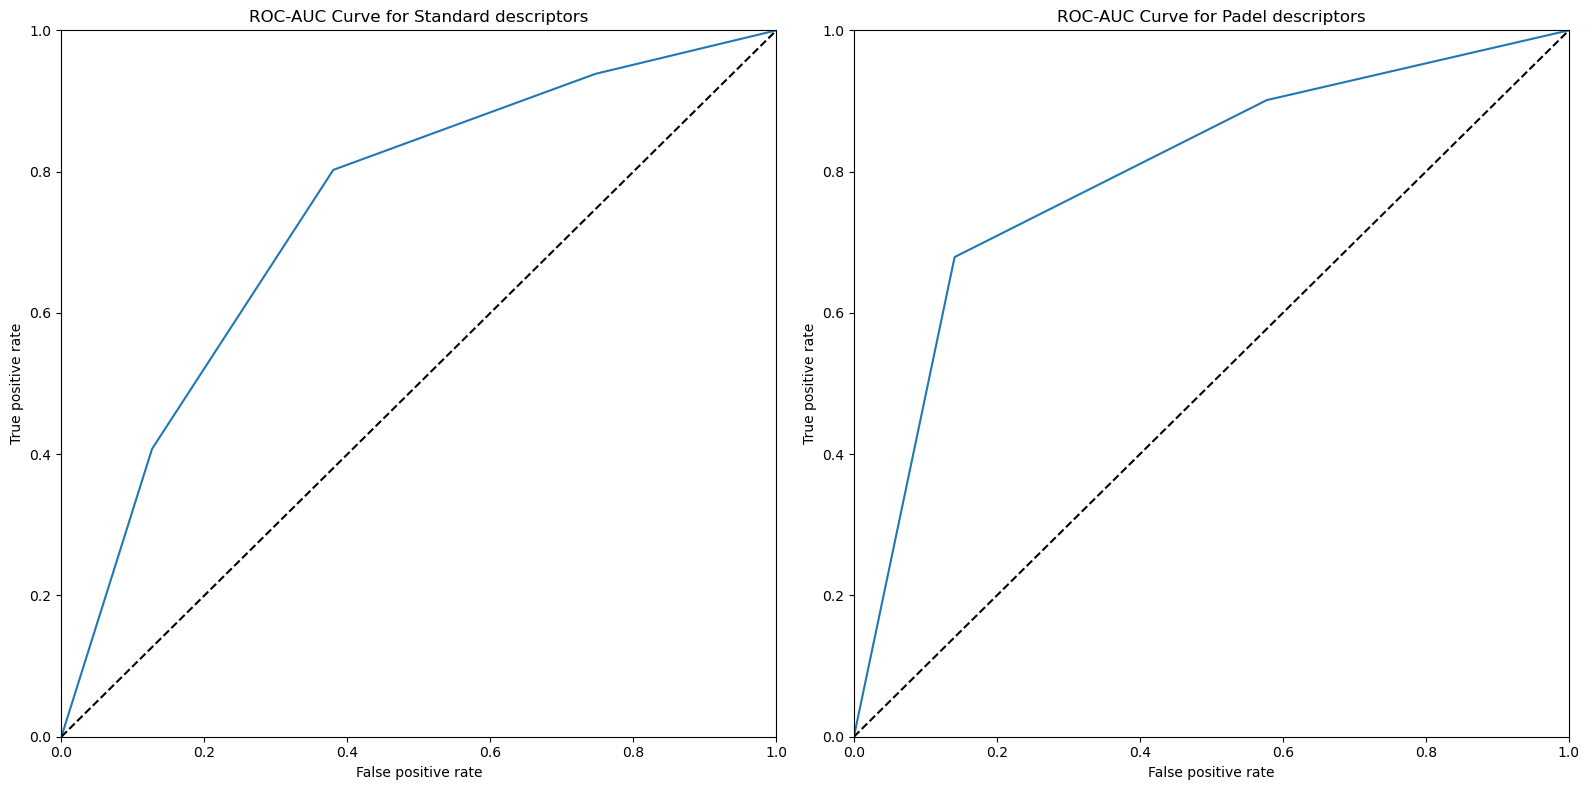

In [48]:
calculate_to_score(pipe, estimator_name='KMeans', param_grid=space, 
                   descriptors_dict=descriptors_dict, target=target, type = 'Full')

In [49]:
pipe = Pipeline([('varsel',VarianceThreshold()),
                 ('scaler',StandardScaler()),
                  ('PCA', PCA(n_components = 50)),
                 ('model_sel',SelectFromModel(LogisticRegression(max_iter=10000))),
                 ('kneighborsclassifier', KNeighborsClassifier())])

100%|███████████████████████████████████████████████| 50/50 [01:15<00:00,  1.50s/trial, best loss: -0.7406584836731895]
{'alpha': 0.49838791031801316, 'metric': 1, 'n_neighbors': 2, 'threshold': 0.34628341224847625, 'weights': 0}
Loss is 0.7406584836731895
Standard deviation is 0.055885525323880886
100%|███████████████████████████████████████████████| 50/50 [01:23<00:00,  1.68s/trial, best loss: -0.7864793938170234]
{'alpha': 1.0492452525471658, 'metric': 3, 'n_neighbors': 2, 'threshold': 0.3702215503236265, 'weights': 0}
Loss is 0.7864793938170234
Standard deviation is 0.08218902303027345


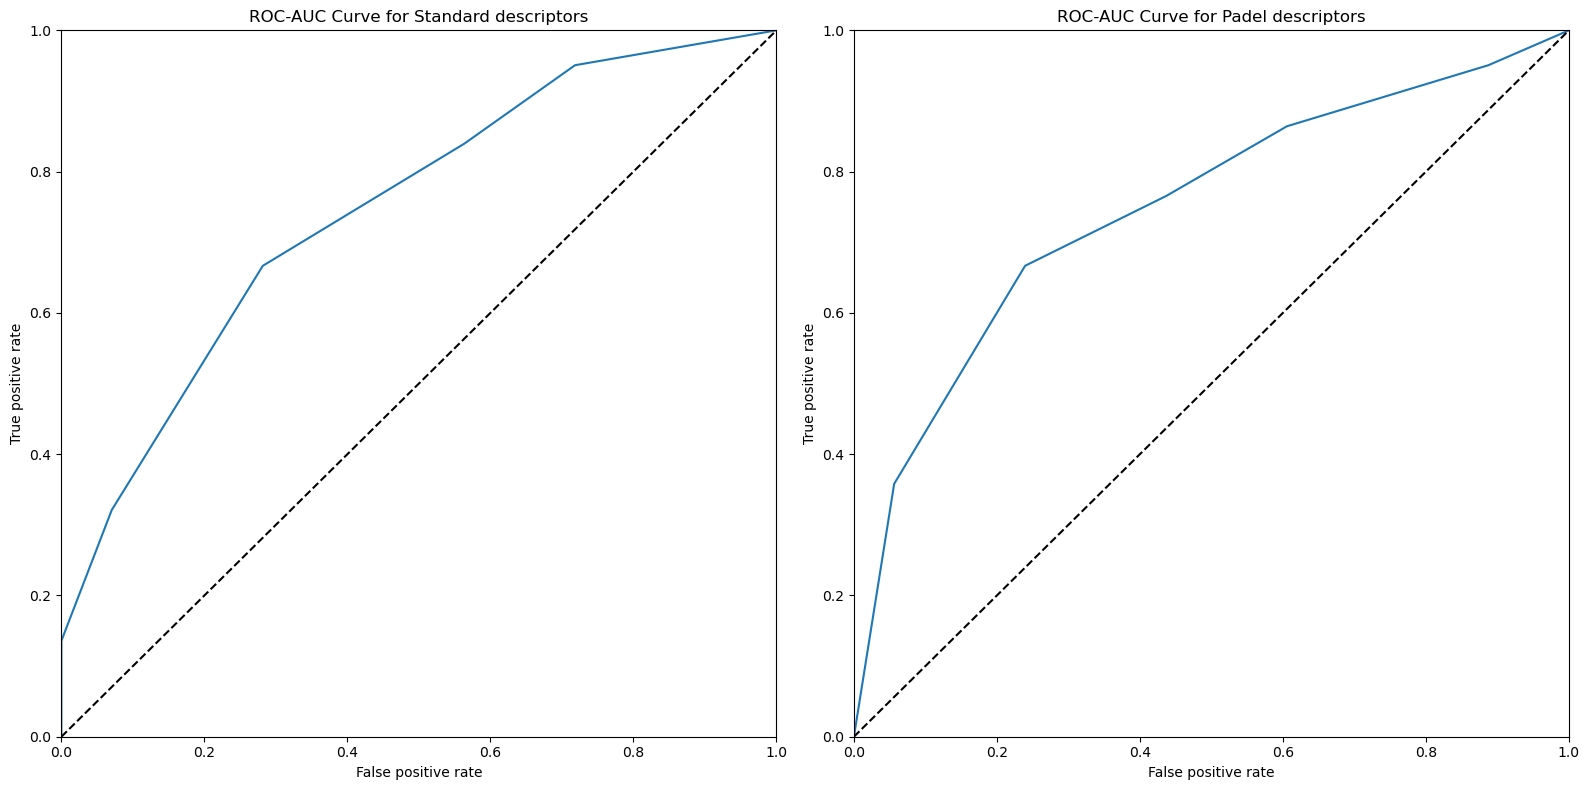

In [50]:
calculate_to_score(pipe, estimator_name='KMeans', param_grid=space,  target=target, type = 'PCA')

Let's save results into pickle file and show the final scores for each algorithm in readable format

In [71]:
with open('score_clf_random_all_temp.pickle', 'wb') as output:
    pickle.dump(scores, output)

In [51]:
pd.DataFrame(scores)

,Descriptors,Full or PCA,Presicion_CV,Stddev_CV,Accuracy,F1 - score,ROC-AUC Score,Estimator,Recall score,Precision score
0,Standard,Full,0.776351,0.124595,0.684211,0.717647,0.746479,SVC,0.753086,0.685393
1,Padel,Full,0.759341,0.066939,0.664474,0.698225,0.722483,SVC,0.728395,0.670455
2,Standard,PCA,0.703766,0.063058,0.644737,0.689655,0.697009,SVC,0.740741,0.645161
3,Padel,PCA,0.771493,0.049098,0.657895,0.701149,0.781082,SVC,0.753086,0.655914
4,Standard,Full,0.740604,0.061088,0.703947,0.730539,0.747870,Logistic Regression,0.753086,0.709302
5,Padel,Full,0.754779,0.049965,0.684211,0.724138,0.763867,Logistic Regression,0.777778,0.677419
6,Standard,PCA,0.728876,0.057919,0.671053,0.702381,0.713615,Logistic Regression,0.728395,0.678161
7,Padel,PCA,0.747337,0.041285,0.697368,0.729412,0.757086,Logistic Regression,0.765432,0.696629
8,Standard,Full,0.810769,0.061827,0.763158,0.775000,0.849939,Random Forest,0.765432,0.784810
9,Padel,Full,0.823132,0.045949,0.664474,0.705202,0.794471,Random Forest,0.753086,0.663043
